# Neural-Network–Based Continuum Background Inpainting for COSI

#### Overview

This notebook provides an introduction to neural-network–based background inpainting for COSI data using the `ContinuumEstimationNN` class in cosipy. The purpose of this tutorial is to demonstrate how machine learning methods can be used to estimate the continuum background. Specifically, here we use a graph-based convolutional neural network. This approach trains a neural network in order to reconstruct (inpaint) the background for regions of the Compton data space (CDS) occupied by a source of interest (currently only tested for point sources). The resulting background estimate can be used directly in COSI analysis.

#### What This Method Does

At a high level, the inpainting procedure consists of the following steps:

1. Project COSI data into the 3D CDS spanned by measured energy (Em), Compton scatter angle (Phi), and sky coordinates (PsiChi)

2. Mask region in the CDS dominated by a point source using the point source response and angular resolution measure (ARM). 

3. Train a neural network on the unmasked sky pixels

4. Predict the background in the masked region and merge the result with the observed data

The sky is discretized using HEALPix, which naturally defines a graph where each pixel is connected to its neighbors. This allows the neural network to propagate information across the sphere while respecting the underlying sky geometry.

#### Training Modes

The inpainting algorithm supports three complementary training modes:

- **Self-supervised** (default)  
  No background model is required. The network learns by randomly masking a fraction of the sky and training itself to reconstruct those pixels.

- **Supervised**  
  A background model is provided and treated as ground truth in the masked regions.

- **Hybrid**  
  A weighted combination of supervised and self-supervised training. This mode leverages an existing background model while remaining robust to modeling uncertainties.

The training mode is selected with a single keyword argument, making it easy to experiment with different strategies.

#### Neural Network Architecture

Two graph-based neural network architectures are available:

- **GCN (Graph Convolutional Network)**  
  A lightweight, four-layer architecture optimized for stability and speed.

- **Graph U-Net**  
  A deeper architecture that captures larger-scale structure through pooling and unpooling operations.

Both models operate directly on HEALPix graphs and are implemented using PyTorch Geometric. GPU acceleration is used automatically when available, but the method also runs on CPUs for smaller datasets and testing.

#### Outputs and Diagnostics

This workflow produces:

- **Inpainted background histogram**: compatible with cosipy
- **Mollweide sky maps**: optional, showing the true, masked, and inpainted data for a given bin of Em and Phi
- **Training-loss diagnostics**: saved during optimization
- **Accuracy evaluation plots**: when a reference background model is available

These diagnostics are designed to help assess both the quality of the final background estimate and the behavior of the neural network during training.

#### Limitations of the Method

The source region in the CDS is masked based on the ARM. However, for the COSI response, the ARM of a source has a long tail. This limits the accuracy of the estimated background, since the source photons in the tail cannot be masked.  

In terms of training the network, most of the infrastructure is in place. However, further development is needed to optimize the network and training. 

#### Tutorial Outline

There are three main parts to this tutorial. First, we will demonstrate the basic functionality of the continuum background estimation class, and use it to get an estimate of the background using the GCN method. Then, instead of a NN-based algorithm, we'll estimate the background using a simple interpolation method (same as was used for DC3). Finally, we will then use the estimated background to perform a spectral fit. This example uses the Crab and total background from DC3. 

### Estimating the background with NN-based inpainting

In [1]:
# Imports:
from cosipy.background_estimation import ContinuumEstimationInterp
from cosipy.background_estimation.ml import ContinuumEstimationNN
from cosipy.util import fetch_wasabi_file
import logging
logging.basicConfig(level=logging.INFO)

%matplotlib inline

13:52:54 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=197598;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=915349;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=714807;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=357844;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

13:52:55 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=659854;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=341913;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

13:52:55 INFO      Starting 3ML!                                                                     ]8;id=889928;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=220172;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=693707;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=878349;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=975241;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=788350;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#136\136]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=200886;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=462424;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

13:52:57 WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=909389;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=639610;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=7735;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=877590;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              


WARNING UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/libpyg.so)


WARNING UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs


WARNING UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs


WARNING UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/torch_spli

The first part of the notebook requires the following files:
1) crab_and_bg_combined_binned_data.h5
2) crab_binned_data.hdf5
3) crab_psr.h5
4) Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5

They can be downloaded using the cells below.

In [4]:
# crab_and_bg_combined_binned_data.h5
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_and_bg_combined_binned_data.h5', checksum = 'f5ee6f356ebc30a3168a1697c4ec2bdc')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_and_bg_combined_binned_data.h5


In [5]:
# crab_binned_data.hdf5
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_binned_data.hdf5', checksum = '405862396dea2be79d7892d6d5bb50d8')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_binned_data.hdf5


In [6]:
# crab_psr.h5
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_psr.h5', checksum = '700ea171dd52a989deb0810b20302b0d')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_psr.h5


In [8]:
# Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5
fetch_wasabi_file('COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5', checksum = '270ba55f0da6bc25d4919709ae6a31c2')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5


Define input files:

In [2]:
data_path = "./"
input_data = data_path + "crab_and_bg_combined_binned_data.h5"
crab_data = data_path + "crab_binned_data.hdf5"
psr_file = data_path + "crab_psr.h5"
background_model = data_path + "Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5"

Define instance of class:

In [3]:
instance = ContinuumEstimationNN()

There is a convenience function that allows you to run the background estimation algorithm with a single command. The command is shown below with all available options. At minimum, you need to pass the input data and point source response file. All optional inputs are shown with their default values, except for `epochs`, which we set to 1 in order to speed up the runtime. See cosipy documentation for more information on the input parameters.

Note: this example notebook is being run with 1 GPU. The code detects this automatically and will utilize GPU acceleration. If no GPUs are detected it will default to CPU. 

In [4]:
instance.estimate_bg(input_data, psr_file, background_model=None,
            training_mode="self", containment=0.6, epochs=1, model_type="gcn",
            nn_model="new", nn_model_file=None, nn_model_savename="inpainting_nn_model",
            lr=1e-3, self_mask_fraction=0.1, lambda_sup=0.5, lambda_self=0.5,
            prefix="inpainted", visualize=False, em_bin=2, phi_bin=4,
            evaluate_only=False, inpainted_file=None,
            evaluate=False, show_plots=False, verbose=False)

INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:GPUs available: 1
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GPU 0: NVIDIA A100-PCIE-40GB (capability 8.0)
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GCN model.


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_estimated_bg.h5
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 2.11 seconds


Now let's do a full run to estimate the background. We will use the supervised mode, and correspondingly we will pass a background model. We will also make evaluation plots.

INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:GPUs available: 1
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GPU 0: NVIDIA A100-PCIE-40GB (capability 8.0)
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GCN model.


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_supervised_600_epochs_0p6containment_estimated_bg.h5


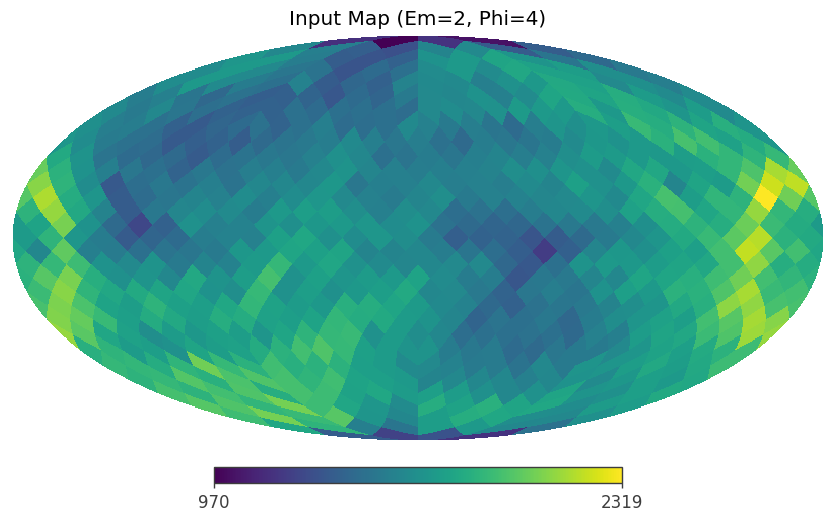

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_supervised_600_epochs_0p6containment_true_E2_Phi4.pdf


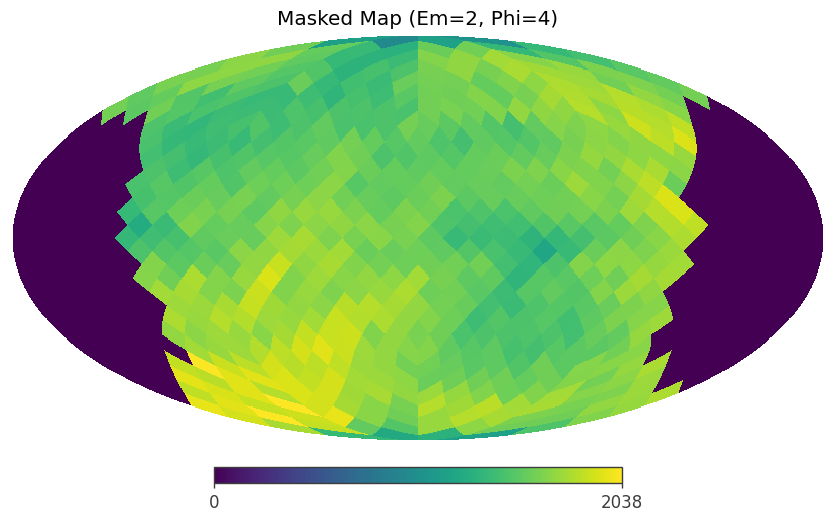

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_supervised_600_epochs_0p6containment_masked_E2_Phi4.pdf


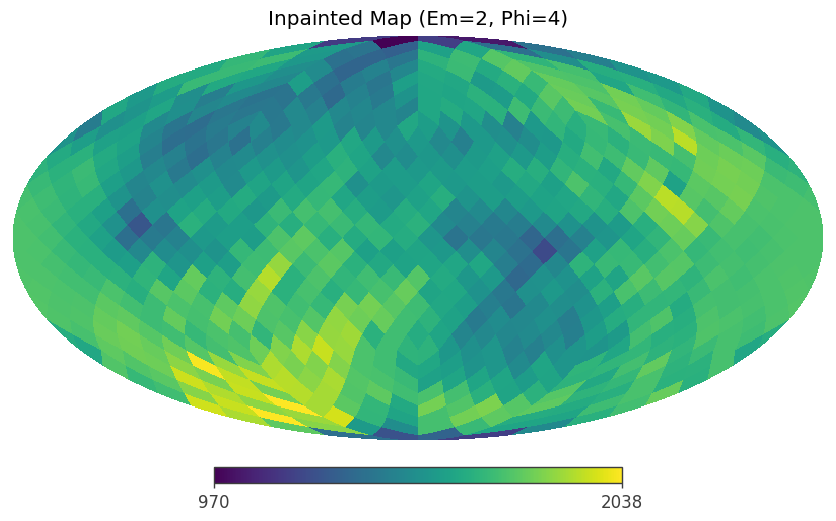

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_supervised_600_epochs_0p6containment_inpainted_E2_Phi4.pdf


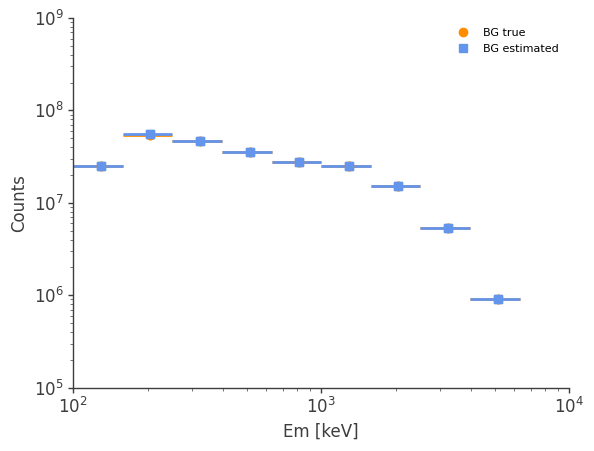

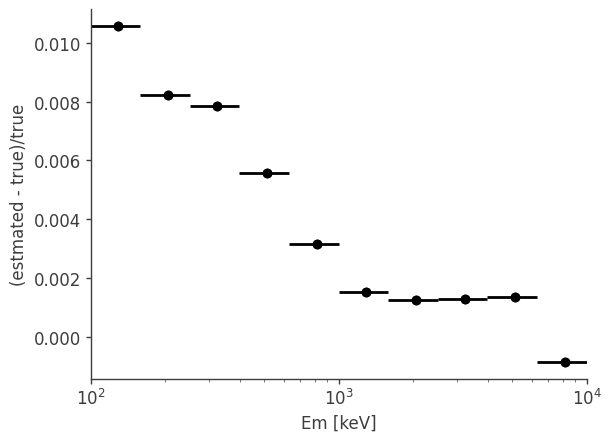

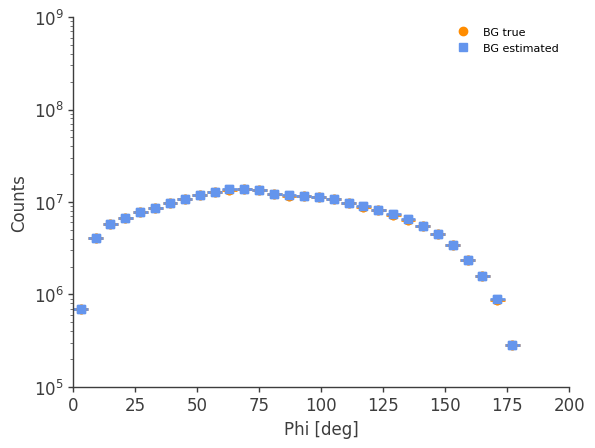

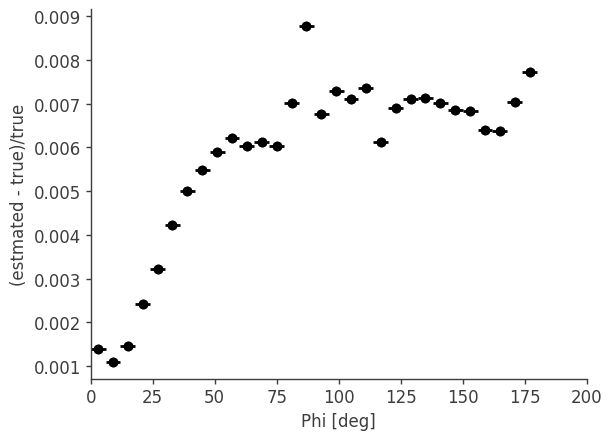

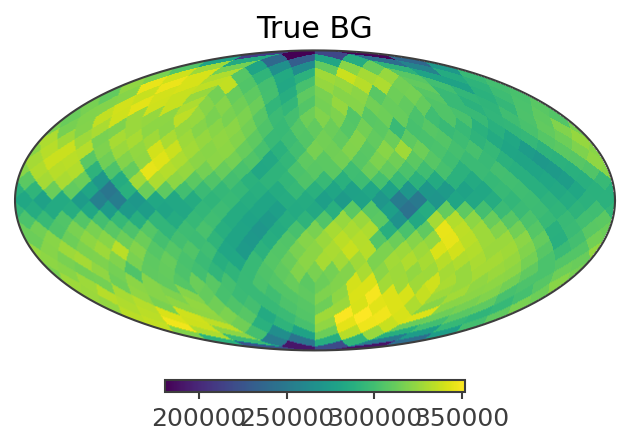

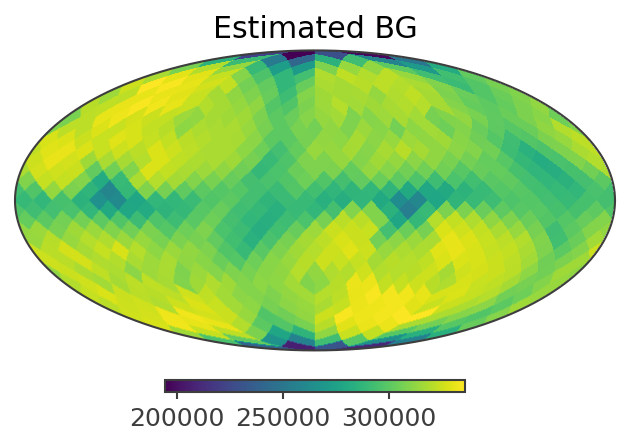


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: divide by zero encountered in divide



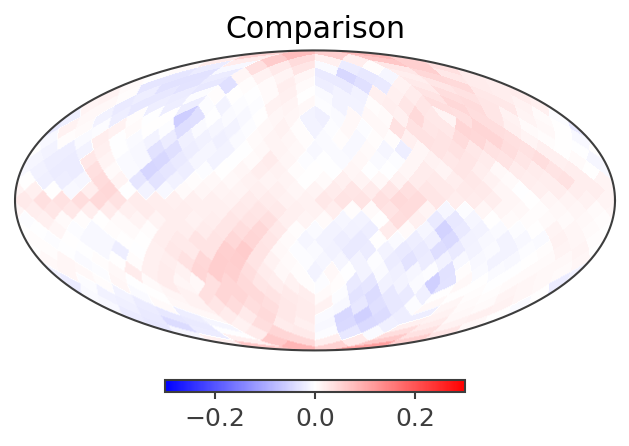

INFO:cosipy.background_estimation.ContinuumEstimationNN:Accuracy plots saved with prefix 'inpainted_supervised_600_epochs_0p6containment_...'
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 604.48 seconds


In [5]:
instance.estimate_bg(input_data, psr_file, background_model=background_model,
        training_mode="supervised", containment=0.6, epochs=600, prefix="inpainted_supervised_600_epochs_0p6containment", 
        evaluate=True, show_plots=True, visualize=True, verbose=False)

Producing the estimted BG map took 604.5 seconds (10.1 minutes). From the diagnostic plots, we see that the agreement with the model is generally within 1% (when projected onto a given axis).

Let's now take a look at the training loss for one of the energy bins:

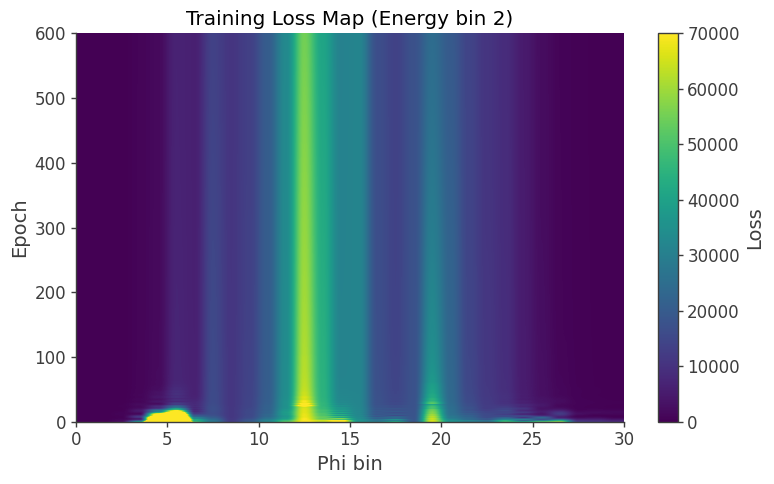

In [6]:
for E in range(2,3):
    instance.plot_training_loss("inpainting_nn_model_training_loss.npy",E,"training_loss",vmax=70000)

The NN model is saved, including the weights, optimizer state, epochs, and training loss. Let's run the estimate again, but this time we'll laod the model from file. We just want to demonstrate the funcionality here, and so we'll set `epochs` to 1. 

In [7]:
instance.estimate_bg(input_data, psr_file, background_model=background_model,
        training_mode="supervised", containment=0.6, epochs=1, prefix="inpainted_example", 
        nn_model="load", nn_model_file="inpainting_nn_model.pth", nn_model_savename="inpainting_nn_model_example", verbose=False)

INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:GPUs available: 1
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GPU 0: NVIDIA A100-PCIE-40GB (capability 8.0)
INFO:cosipy.background_estimation.ContinuumEstimationNN:loading NN model...
INFO:cosipy.background_estimation.ContinuumEstimationNN:Loaded NN model (weights only) from inpainting_nn_model.pth


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_example_estimated_bg.h5
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 1.41 seconds


### Estimating the background with simple interpolation inpainting
Instead of NN-based inpainting, we can also do a simple interpolation. This is the original method presented with DC3, and it's useful as a baseline to gauge the improvement from the NN-based method. For each masked pixel, the algorithm moves to the left till it finds the first non-masked pixel, and then moves to the right till findinging the first non-masked pixel. The inpainted value is taken as the mean of left and right. This is easy to implement because we have a healpix skymap in ring order. All other methods are inhereted from the ContinuumEstimationNN class. Let's run it:

INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_simple_estimated_bg.h5


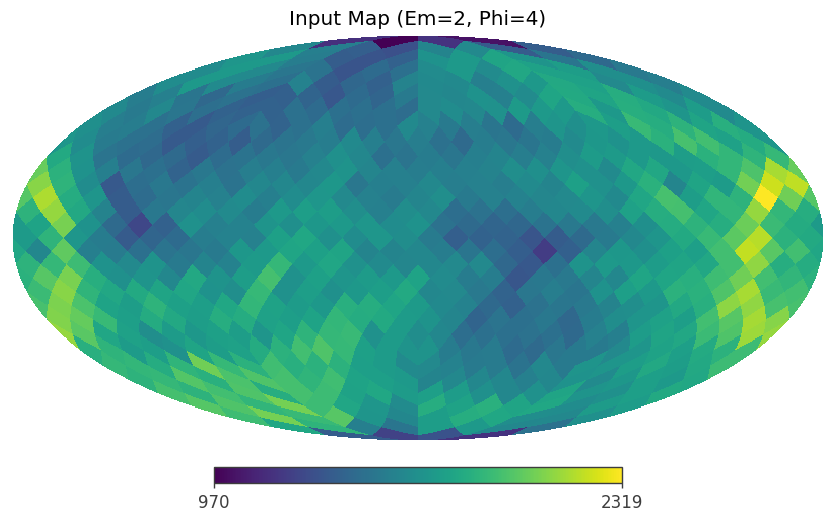

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_simple_true_E2_Phi4.pdf


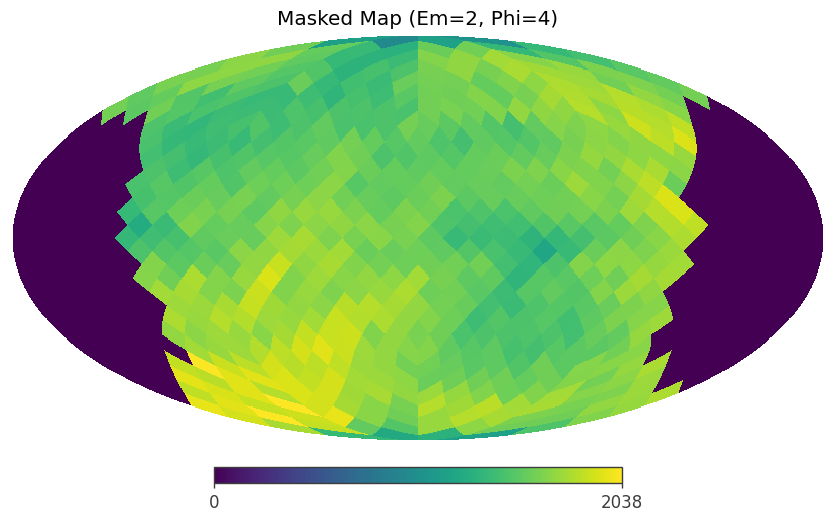

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_simple_masked_E2_Phi4.pdf


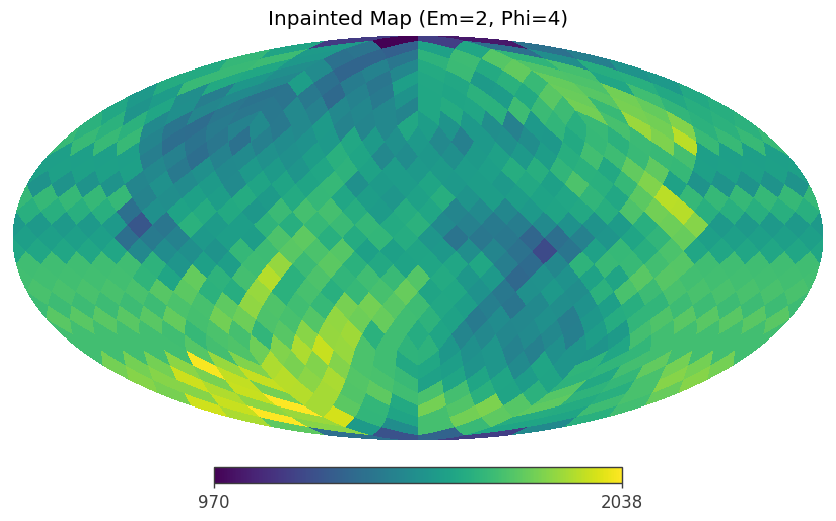

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_simple_inpainted_E2_Phi4.pdf


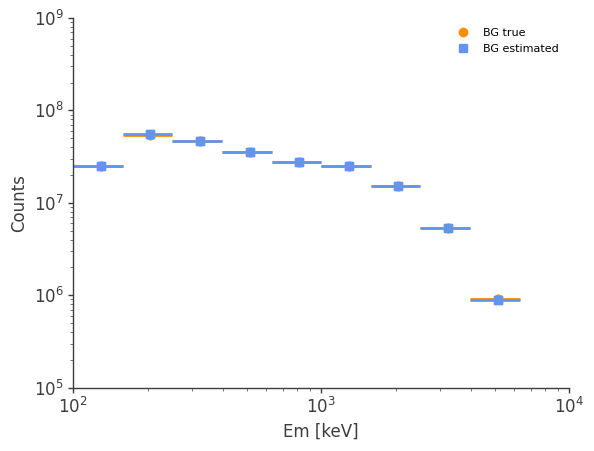

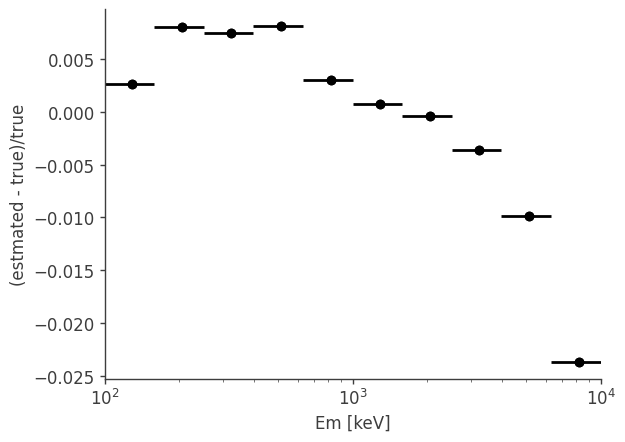

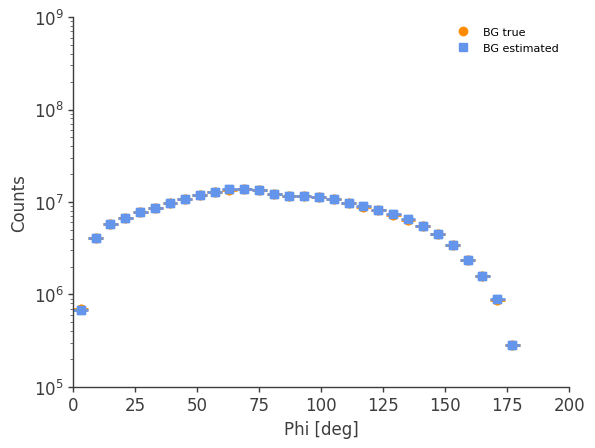

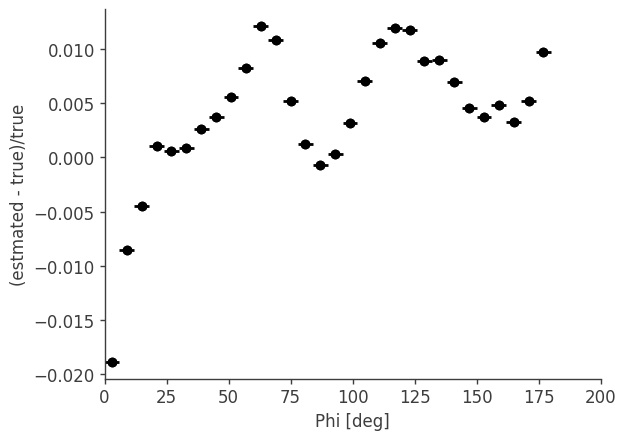

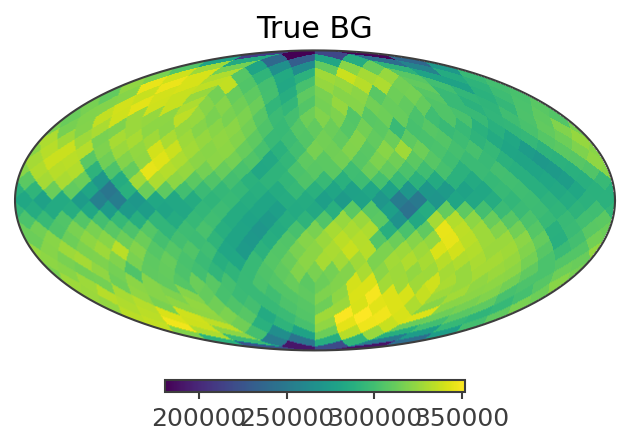

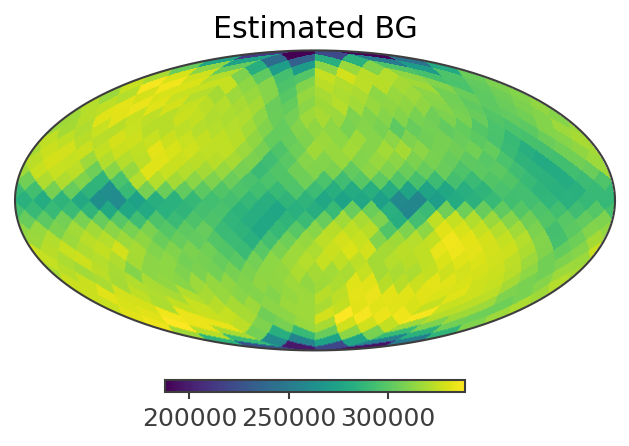


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: divide by zero encountered in divide



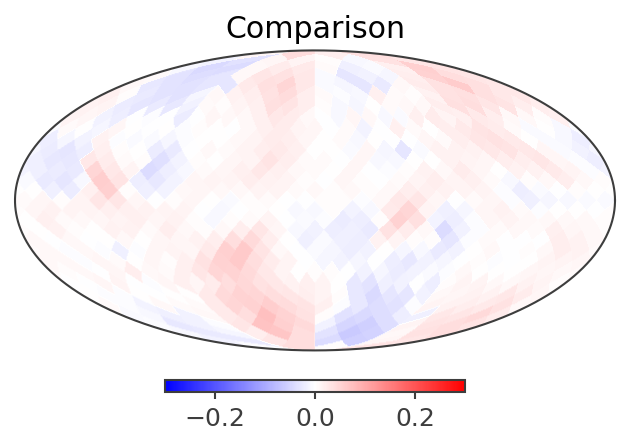

INFO:cosipy.background_estimation.ContinuumEstimationNN:Accuracy plots saved with prefix 'inpainted_simple_...'
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 3.29 seconds


In [8]:
instance = ContinuumEstimationInterp()
instance.estimate_bg(input_data, psr_file, background_model=background_model,
                prefix="inpainted_simple", evaluate=True, show_plots=True, visualize=True, verbose=False)

The agreement seems to be a bit worse compared to the NN-based method (within ~2%). 

### Spectral fit using the estimated background
This example is nearly identical to the spectral fit example in docs/api/interfaces/examples/crab. The main difference is that instead of the ideal BG file, we will use the estimated BG calculated in the previous section.

Imports:

In [9]:
from cosipy import test_data, BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

import sys

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import astromodels

import numpy as np
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from pathlib import Path

import os

In addition to the files above, you will need the following files:

1. inputs_crab.yaml
2. crab_DC2_astromodel.yaml
2. DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
3. ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5

These can be downloaded using the cells below:

In [18]:
# inputs_crab.yaml
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimationNN/inputs_crab.yaml', checksum = 'dd30283e1809ccc51d75ad22cf20e766')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/cosipy_tutorials/background_estimationNN/inputs_crab.yaml


In [19]:
# crab_DC2_astromodel.yaml
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_DC2_astromodel.yaml', checksum = 'b8366b8e09ede0f29581d1ec466628c6')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/cosipy_tutorials/background_estimationNN/crab_DC2_astromodel.yaml


In [20]:
# DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits', checksum = 'ca94ff1d7a73c1f41479aaf598807673')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/DC3/Data/Orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori


In [23]:
# ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5 
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5', checksum = '7121f094be50e7bfe9b31e53015b0e85')

INFO:cosipy.util.data_fetching:Downloading cosi-pipeline-public/COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5


Define all input files:

In [10]:
data_path = "./"
total_data = os.path.join(data_path,"crab_and_bg_combined_binned_data.h5")
crab_data = os.path.join(data_path, "crab_binned_data.hdf5")
psr_file = os.path.join(data_path,"crab_psr.h5")
background_model = os.path.join(data_path,"Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")
input_yaml = os.path.join(data_path,"inputs_crab.yaml")
ori_file = os.path.join(data_path,"DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits")
dr_file = os.path.join(data_path,"ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5")

The estimated BG file was calculated at the last step:

In [11]:
estimated_bg = "inpainted_supervised_600_epochs_0p6containment_estimated_bg.h5"
estimated_bg_simple = "inpainted_simple_estimated_bg.h5"

Load files:

In [12]:
# Orientation file:
sc_orientation = SpacecraftHistory.open(ori_file)

# Detector response:
dr = FullDetectorResponse.open(dr_file)

# Load Crab data:
crab = BinnedData(input_yaml)
crab.load_binned_data_from_hdf5(binned_data=crab_data)

# Load BG model true:
bg = BinnedData(input_yaml)
bg.load_binned_data_from_hdf5(binned_data=background_model)

# Load BG model estimated:
bg_est = BinnedData(input_yaml)
bg_est.load_binned_data_from_hdf5(binned_data=estimated_bg)

# Load BG model estimated simple:
bg_est_simple = BinnedData(input_yaml)
bg_est_simple.load_binned_data_from_hdf5(binned_data=estimated_bg_simple)

# Load total data:
total = BinnedData(input_yaml)
total.load_binned_data_from_hdf5(binned_data=total_data)

INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml


Define interfaces below. Here we will use the FreeNormBinnedBackground interface. The only difference is that we will use the estimated BG instead of the true BG. 

In [13]:
# ------- Interfaces ----------

# Total data:
data = EmCDSBinnedData(total.binned_data.project('Em', 'Phi', 'PsiChi'))

# Response
instrument_response = BinnedInstrumentResponse(dr, data)

# BG:
bkg_dist = {"total_bkg":bg_est.binned_data.project('Em', 'Phi', 'PsiChi')}

#for bckfile in bkg_dist.keys():
#        bkg_dist[bckfile] += sys.float_info.min
        
bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = False)

psr = BinnedThreeMLPointSourceResponse(data = data,
                                        instrument_response = instrument_response,
                                        sc_history=sc_orientation,
                                        energy_axis = dr.axes['Ei'],
                                        polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                        nside = 2*data.axes['PsiChi'].nside)

response = BinnedThreeMLModelFolding(data = data, point_source_response = psr)

like_fun = PoissonLikelihood(data, response, bkg)

cosi = ThreeMLPluginInterface('cosi',
                            like_fun,
                            response,
                            bkg)


WARNING RuntimeWarning: divide by zero encountered in divide



Nuisance parameters, model, and plugin:

In [14]:
# Nuisance parameter guess, bounds, etc.
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,  # background parameter
                                    1,  # initial value of parameter
                                    min_value=0,  # minimum value of parameter
                                    max_value= 100,  # maximum value of parameter
                                    delta=0.05,  # initial step used by fitting engine
                                    unit = u.Hz
                                          )
    
# Load the astromodel for the Crab (this is the same model as 
# used in the DC2 Crab tutorial):
model = astromodels.load_model('./crab_DC2_astromodel.yaml')


# Define plugin and fit:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)  

14:06:39 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=408782;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=842630;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

Perform likelihood fit:

In [15]:
like = JointLikelihood(model, plugins, verbose = False)

like.fit()

14:06:43 INFO      set the minimizer to minuit                                              ]8;id=701321;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=617277;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/classicMLE/joint_likelihood.py#994\994]8;;\

INFO:cosipy.response.threeml_point_source_response:... Calculating point source response ...
INFO:cosipy.response.threeml_point_source_response:--> done (source name : source)

WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log

14:07:13 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=230012;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=607988;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(3.243 +/- 0.009) x 10^-5,1 / (keV s cm2)
total_bkg,(3.57217 +/- 0.00031) x 10,Hz


...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1591385619.4884508
total,-1591385619.4884508


Values of statistical measures:

,statistical measures
AIC,-3182771234.9768496
BIC,-3182771214.281757


(                                 value  negative_error  positive_error  \
 source.spectrum.main.Band.K   0.000032   -8.268109e-08    8.567800e-08   
 total_bkg                    35.721728   -3.062963e-03    3.050569e-03   
 
                                     error             unit  
 source.spectrum.main.Band.K  8.417955e-08  1 / (keV s cm2)  
 total_bkg                    3.056766e-03               Hz  ,
           -log(likelihood)
 cosi   -1591385619.4884508
 total  -1591385619.4884508)

Compare best-fit to injected source:

14:07:29 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=350057;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=401087;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=702322;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=607582;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

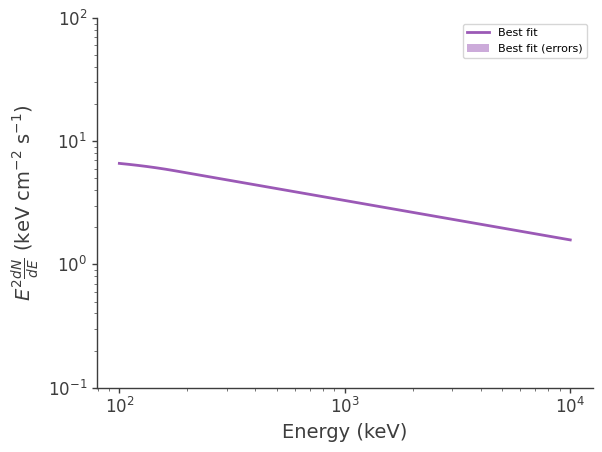

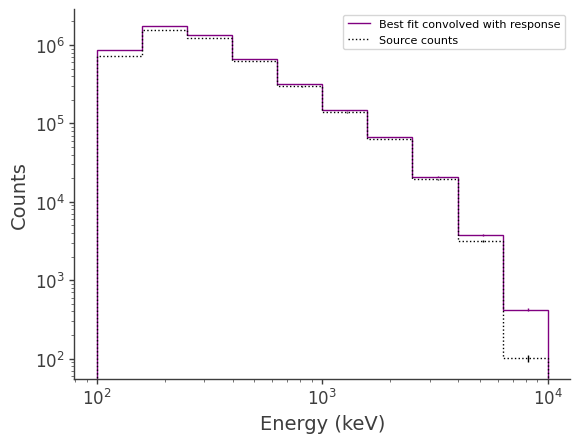

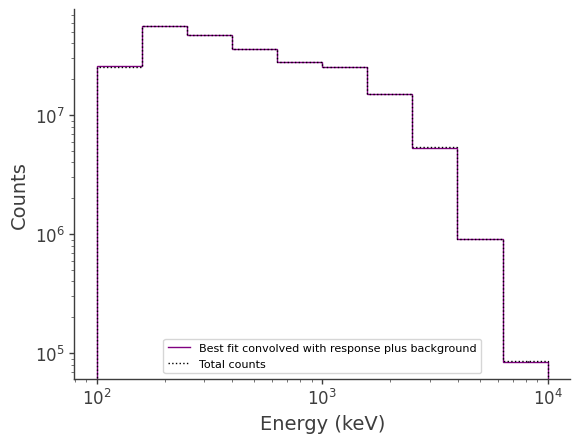

In [16]:
# Get expectation

results = like.results


#print(results.display())

parameters = {par.name:results.get_variates(par.path)
                  for par in results.optimized_model["source"].parameters.values()
                  if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

#print(results.optimized_model["source"])
    
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    #flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = crab.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation(copy = True)    
exp_est = expectation # for later comparison

# Plot the fitted and injected spectra
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
#ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

ax.set_ylim(.1,100)
plt.show()

# Plot the fitted spectrum convolved with the response, as well as the simulated source counts
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
#ax.stairs(expectation_inj.project('Em').todense().contents, binned_energy_edges, color='blue', label = "Injected spectrum convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(crab.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, crab.binned_data.project('Em').todense().contents, yerr=np.sqrt(crab.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

# Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts  
expectation_bkg = bkg.expectation(copy = True)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

Let's do the same thing for the simple inpainting. It's the same procedure, and so we'll run everything together. 

INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml


14:08:35 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=114718;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=208865;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

14:08:35 INFO      set the minimizer to minuit                                              ]8;id=421350;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=512278;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/classicMLE/joint_likelihood.py#994\994]8;;\

INFO:cosipy.response.threeml_point_source_response:... Calculating point source response ...
INFO:cosipy.response.threeml_point_source_response:--> done (source name : source)

WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log

14:09:03 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=868136;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=229769;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

...

,-log(likelihood)
cosi,-1591401274.5105834
total,-1591401274.5105834


Values of statistical measures:

,statistical measures
AIC,-3182802545.021115
BIC,-3182802524.326022


         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=814663;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=34050;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=710629;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=150383;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

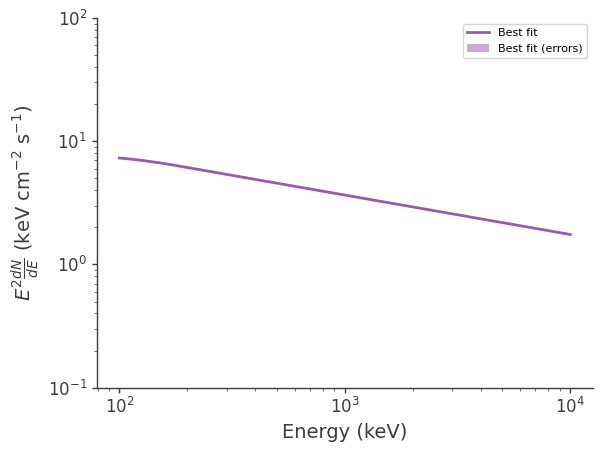

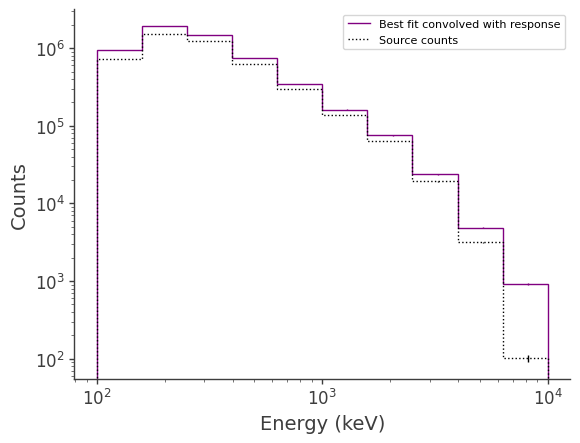

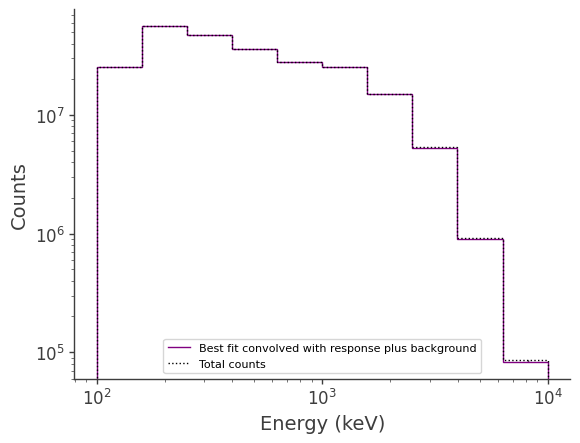

In [17]:
# Orientation file:
sc_orientation = SpacecraftHistory.open(ori_file)

# Detector response:
dr = FullDetectorResponse.open(dr_file)

# Load Crab data:
crab = BinnedData(input_yaml)
crab.load_binned_data_from_hdf5(binned_data=crab_data)

# Load BG model true:
bg = BinnedData(input_yaml)
bg.load_binned_data_from_hdf5(binned_data=background_model)

# Load BG model estimated:
bg_est = BinnedData(input_yaml)
bg_est.load_binned_data_from_hdf5(binned_data=estimated_bg)

# Load BG model estimated simple:
bg_est_simple = BinnedData(input_yaml)
bg_est_simple.load_binned_data_from_hdf5(binned_data=estimated_bg_simple)

# Load total data:
total = BinnedData(input_yaml)
total.load_binned_data_from_hdf5(binned_data=total_data)

# ------- Interfaces ----------

# Total data:
data = EmCDSBinnedData(total.binned_data.project('Em', 'Phi', 'PsiChi'))

# Response
instrument_response = BinnedInstrumentResponse(dr, data)

# BG:
bkg_dist = {"total_bkg":bg_est_simple.binned_data.project('Em', 'Phi', 'PsiChi')}
#for bckfile in bkg_dist.keys():
#        bkg_dist[bckfile] += sys.float_info.min
        
bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = False)

psr = BinnedThreeMLPointSourceResponse(data = data,
                                        instrument_response = instrument_response,
                                        sc_history=sc_orientation,
                                        energy_axis = dr.axes['Ei'],
                                        polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                        nside = 2*data.axes['PsiChi'].nside)

response = BinnedThreeMLModelFolding(data = data, point_source_response = psr)

like_fun = PoissonLikelihood(data, response, bkg)

cosi = ThreeMLPluginInterface('cosi',
                            like_fun,
                            response,
                            bkg)

# Nuisance parameter guess, bounds, etc.
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,  # background parameter
                                    1,  # initial value of parameter
                                    min_value=0,  # minimum value of parameter
                                    max_value= 100,  # maximum value of parameter
                                    delta=0.05,  # initial step used by fitting engine
                                    unit = u.Hz
                                          )
    
# Load the astromodel for the Crab (this is the same model as 
# used in the DC2 Crab tutorial):
model = astromodels.load_model('./crab_DC2_astromodel.yaml')


# Define plugin and fit:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)  

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

# Get expectation

results = like.results


#print(results.display())

parameters = {par.name:results.get_variates(par.path)
                  for par in results.optimized_model["source"].parameters.values()
                  if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

#print(results.optimized_model["source"])
    
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    #flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = crab.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation(copy = True)    
exp_est_simple = expectation # for later comparison

# Plot the fitted and injected spectra
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
#ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

ax.set_ylim(.1,100)
plt.show()

# Plot the fitted spectrum convolved with the response, as well as the simulated source counts
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
#ax.stairs(expectation_inj.project('Em').todense().contents, binned_energy_edges, color='blue', label = "Injected spectrum convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(crab.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, crab.binned_data.project('Em').todense().contents, yerr=np.sqrt(crab.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

# Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts  
expectation_bkg = bkg.expectation(copy = True)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

Finally, let's see what we get using the ideal BG. 

INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml
INFO:yayc.configurator:Using configuration file at ./inputs_crab.yaml


14:11:05 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=346398;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=32617;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

14:11:05 INFO      set the minimizer to minuit                                              ]8;id=558430;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=263220;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/classicMLE/joint_likelihood.py#994\994]8;;\

INFO:cosipy.response.threeml_point_source_response:... Calculating point source response ...
INFO:cosipy.response.threeml_point_source_response:--> done (source name : source)


14:11:35 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=573625;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=315275;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

...

,-log(likelihood)
cosi,-1591705157.1250365
total,-1591705157.1250365


Values of statistical measures:

,statistical measures
AIC,-3183410310.250021
BIC,-3183410289.5549283


         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=878335;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=548787;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=923149;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=26314;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

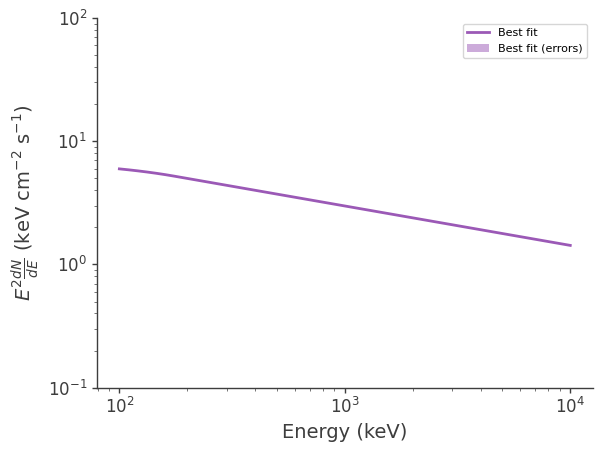

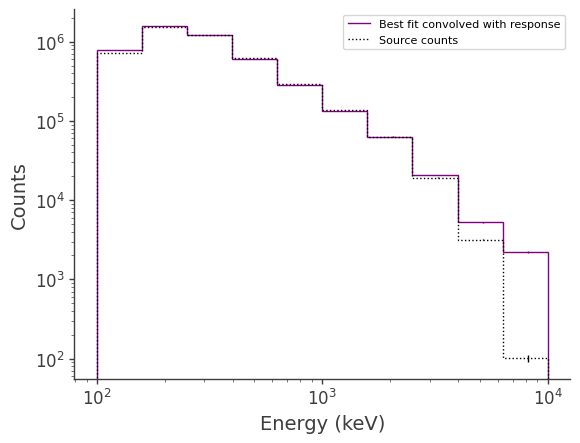

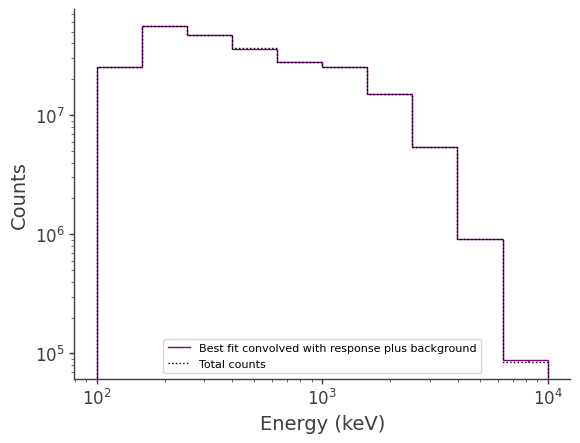

In [18]:
# Orientation file:
sc_orientation = SpacecraftHistory.open(ori_file)

# Detector response:
dr = FullDetectorResponse.open(dr_file)

# Load Crab data:
crab = BinnedData(input_yaml)
crab.load_binned_data_from_hdf5(binned_data=crab_data)

# Load BG model true:
bg = BinnedData(input_yaml)
bg.load_binned_data_from_hdf5(binned_data=background_model)

# Load BG model estimated:
bg_est = BinnedData(input_yaml)
bg_est.load_binned_data_from_hdf5(binned_data=estimated_bg)

# Load BG model estimated simple:
bg_est_simple = BinnedData(input_yaml)
bg_est_simple.load_binned_data_from_hdf5(binned_data=estimated_bg_simple)

# Load total data:
total = BinnedData(input_yaml)
total.load_binned_data_from_hdf5(binned_data=total_data)

# ------- Interfaces ----------

# Total data:
data = EmCDSBinnedData(total.binned_data.project('Em', 'Phi', 'PsiChi'))

# Response
instrument_response = BinnedInstrumentResponse(dr, data)

# BG:
bkg_dist = {"total_bkg":bg.binned_data.project('Em', 'Phi', 'PsiChi')}

#for bckfile in bkg_dist.keys():
#        bkg_dist[bckfile] += sys.float_info.min
        
bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = False)

psr = BinnedThreeMLPointSourceResponse(data = data,
                                        instrument_response = instrument_response,
                                        sc_history=sc_orientation,
                                        energy_axis = dr.axes['Ei'],
                                        polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                        nside = 2*data.axes['PsiChi'].nside)

response = BinnedThreeMLModelFolding(data = data, point_source_response = psr)

like_fun = PoissonLikelihood(data, response, bkg)

cosi = ThreeMLPluginInterface('cosi',
                            like_fun,
                            response,
                            bkg)

# Nuisance parameter guess, bounds, etc.
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,  # background parameter
                                    1,  # initial value of parameter
                                    min_value=0,  # minimum value of parameter
                                    max_value= 100,  # maximum value of parameter
                                    delta=0.05,  # initial step used by fitting engine
                                    unit = u.Hz
                                          )
    
# Load the astromodel for the Crab (this is the same model as 
# used in the DC2 Crab tutorial):
model = astromodels.load_model('./crab_DC2_astromodel.yaml')


# Define plugin and fit:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)  

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

# Get expectation

results = like.results


#print(results.display())

parameters = {par.name:results.get_variates(par.path)
                  for par in results.optimized_model["source"].parameters.values()
                  if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

#print(results.optimized_model["source"])
    
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    #flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = crab.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation(copy = True)    
exp_true = expectation # for later comparison

# Plot the fitted and injected spectra
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
#ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

ax.set_ylim(.1,100)
plt.show()

# Plot the fitted spectrum convolved with the response, as well as the simulated source counts
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
#ax.stairs(expectation_inj.project('Em').todense().contents, binned_energy_edges, color='blue', label = "Injected spectrum convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(crab.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, crab.binned_data.project('Em').todense().contents, yerr=np.sqrt(crab.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

# Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts  
expectation_bkg = bkg.expectation(copy = True)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()

## Summary:

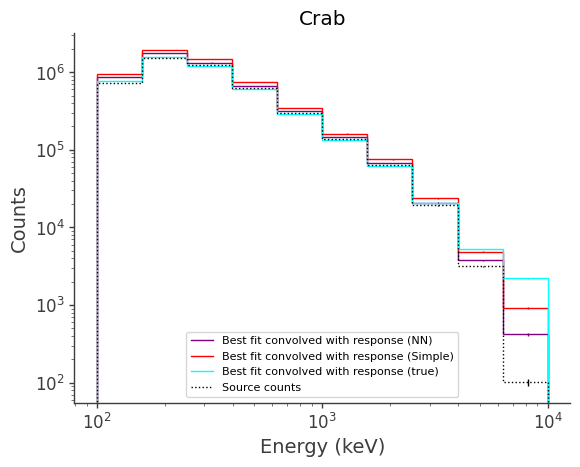

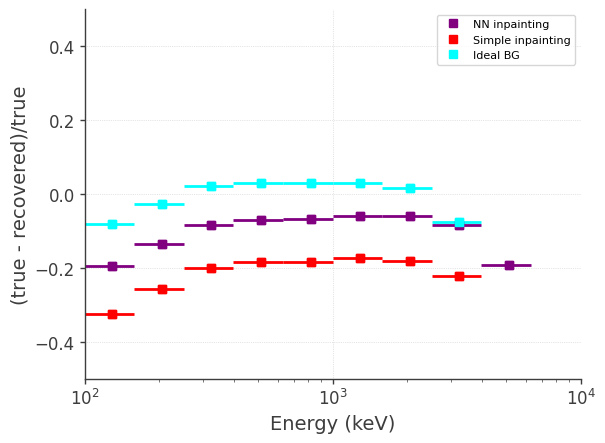

In [47]:
# Plot the fitted spectrum convolved with the response, as well as the simulated source counts
fig,ax = plt.subplots()

ax.stairs(exp_est.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response (NN)")
ax.errorbar(binned_energy, exp_est.project('Em').todense().contents, yerr=np.sqrt(exp_est.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)

ax.stairs(exp_est_simple.project('Em').todense().contents, binned_energy_edges, color='red', label = "Best fit convolved with response (Simple)")
ax.errorbar(binned_energy, exp_est_simple.project('Em').todense().contents, yerr=np.sqrt(exp_est_simple.project('Em').todense().contents), color='red', linewidth=0, elinewidth=1)

ax.stairs(exp_true.project('Em').todense().contents, binned_energy_edges, color='cyan', label = "Best fit convolved with response (true)")
ax.errorbar(binned_energy, exp_true.project('Em').todense().contents, yerr=np.sqrt(exp_est.project('Em').todense().contents), color='cyan', linewidth=0, elinewidth=1)

ax.stairs(crab.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, crab.binned_data.project('Em').todense().contents, yerr=np.sqrt(crab.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()
plt.title("Crab")
plt.show()

# fractional residuals:
fig,ax = plt.subplots()

xerr = crab.binned_data.axes['Em'].widths.value / 2.0

# NN inpainted:
x = (crab.binned_data.project('Em').todense().contents - exp_est.project('Em').todense().contents) / crab.binned_data.project('Em').todense().contents
plt.semilogx(binned_energy, x, label="NN inpainting", ls="", marker="s", color="purple")
plt.errorbar(binned_energy, x, xerr=xerr, ls="", marker="s", color="purple")

# simple inpainted:
x = (crab.binned_data.project('Em').todense().contents - exp_est_simple.project('Em').todense().contents) / crab.binned_data.project('Em').todense().contents
plt.semilogx(binned_energy, x, label="Simple inpainting", ls="", marker="s", color="red")
plt.errorbar(binned_energy, x, xerr=xerr, ls="", marker="s", color="red")

# True:
x = (crab.binned_data.project('Em').todense().contents - exp_true.project('Em').todense().contents) / crab.binned_data.project('Em').todense().contents
plt.semilogx(binned_energy, x, label="Ideal BG", ls="", marker="s", color="cyan")
plt.errorbar(binned_energy, x, xerr=xerr, ls="", marker="s", color="cyan")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("(true - recovered)/true")

plt.legend(loc=1)
plt.ylim(-0.5,0.5)
plt.xlim(1e2,1e4)
plt.grid(ls=":",color="grey",alpha=0.4)
plt.show()

input: norm = 3.07e-5 

estimated BG NN: norm =  (3.243 +/- 0.009)e-5, logL = 1591385619.4884508   

estimated BG simple: norm =  (3.589 +/- 0.009)e-5, logL = 1591401274.5105834   

ideal BG: norm = (2.927 +/- 0.009)e-5, logL = 1591705157.1250365 

Comparing estimated BG (simple) to true BG:
$2 \Delta \mathrm{logL}$ = 607765.2 $\implies \sigma = 780$ (true BG is preferred)

Comparing estimated BG simple to GCN:
$2 \Delta \mathrm{logL}$ = 31310.0 $\implies \sigma = 177$ (simple inpainting is preferred)

Thus, the ideal BG performs significanlty better than the estimated, as expected. The NN estimate gives a normalization closer to the true value. The counts also look better at most energies (except for the last 2 bins). However, the simple alogirthm gives a significantly better TS compared to the NN-based inpainting. The next step is to improve the estimation algorithm to get closer to the ideal BG.